In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter
pd.set_option('display.max_colwidth', 200)

In [2]:
os.chdir('Your_Working_Directory')

In [3]:
f = 'included_articles.csv'
df = pd.read_csv(f)
df['Year'] = df['Year'].str.strip()
df.loc[df['Year']=='', 'Year'] = np.nan
df['Year'] = df['Year'].astype('Int64')
print(df['Included'].unique())
df = df.rename(columns={'ID': 'EPPIReviewer ID'})
print(df['EPPIReviewer ID'].nunique(), df.shape)
df.head()

['I']
204 (204, 6)


,Included,EPPIReviewer ID,ShortTitle,Title,Journal,Year
0,I,110105526,Ajiferuke (2020),Correction and retraction practices in library and information science journals,Journal of Librarianship and Information Science,2020
1,I,110101889,Al-Ghareeb (2018),Retraction of publications in nursing and midwifery research: A systematic review.,International journal of nursing studies,2018
2,I,110237510,Alvaro (2013),Retractions in chemistry: Prevalence and impact,ABSTRACTS OF PAPERS OF THE AMERICAN CHEMICAL SOCIETY,2013
3,I,110238073,An analysis of citations... (Gabehart),An analysis of citations to retracted articles in the scientific literature,NaN,<NA>
4,I,110103569,Avenell (2018),"Research misconduct can promote overtreatment. A multi-institutional case study from Japan, with implications for osteoporosis management with vitamin K",BMJ Evidence-Based Medicine,2018


In [4]:
f = 'data/PostCitationRetraction-Data-EH-Cleaned.csv'
data = pd.read_csv(f)
data = data.rename(columns={"What is the paper's EPPIReviewer ID?": "EPPIReviewer ID"})
print(data.shape)
data = data.merge(df[['EPPIReviewer ID', 'Year']])
print(data.shape)

print(data.shape, data['EPPIReviewer ID'].nunique())
data.head(2)

(146, 19)
(146, 20)
(146, 20) 146


,What is the citation for the paper?,EPPIReviewer ID,Does this paper consider subjects of study?,Please specify - Selected Choice,What is the sampling methodology? - Selected Choice,What is the sampling methodology? - Other - Text,DataSource_Publications,DataSource_Publications_Other,DataSource_Citations,DataSource_Citations_Other,"Does this paper consider citation sentiment (e.g., positive-neutral-negative) or awareness (retraction status mentioned/non-mentioned)?","For publications that assessed citation sentiment and/or awareness, what taxonomies were used? - Selected Choice","For publications that assessed citation sentiment and/or awareness, what taxonomies were used? - Other - Text",Does this paper measure or describe epistemic harm manifesting from post-retraction citations? - Selected Choice,WashoutPeriod,WashoutPeriod_FreeText,Does this study report both pre and post-retraction citation or citations of retracted vs. unretracted publications?,Does the study compare pre- and post-retraction citation rates or retracted vs. unretracted citation rates?,sampling_methodology_consolidated,Year
0,Wang (2023) Review of retracted papers in the field of neurology. European journal of neurology,110101865,Yes,Health/Life Science/Medical--Neurology,Subject related,NaN,Cochrane Library;Embase;PubMed;Retraction Watch;Web of Science,NaN,Not reported,NaN,No,NaN,NaN,No,The authors do not mention washout periods,NaN,"Yes, pre- and post-retraction citations",No,Subject related,2023
1,Wadgave (2022) Evaluation of retracted publications in Dentistry: A systematic review. Indian journal of medical ethics,110101885,Yes,Health/Life Science/Medical--Dental,Subject related,NaN,PubMed,NaN,Google Scholar,NaN,No,NaN,NaN,No,The authors do not mention washout periods,NaN,"Yes, pre- and post-retraction citations",No,Subject related,2022


# Data Sources

In [5]:
col0 = 'EPPIReviewer ID'
col1 = 'DataSource_Publications'
col2 = 'DataSource_Publications_Other'
col3 = 'DataSource_Citations'
col4 = 'DataSource_Citations_Other'

source_count_prep = data[[col0, col1, col2, col3, col4]].copy()
source_count_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   EPPIReviewer ID                146 non-null    int64 
 1   DataSource_Publications        146 non-null    object
 2   DataSource_Publications_Other  11 non-null     object
 3   DataSource_Citations           146 non-null    object
 4   DataSource_Citations_Other     7 non-null      object
dtypes: int64(1), object(4)
memory usage: 5.8+ KB


In [6]:
source_count_prep = source_count_prep.fillna('NA')

source_count = [['EPPI_ID', '#PubSources', 'PubSources', '#CitSources', 'CitSources']]
for row in source_count_prep.values.tolist():
    eppi_id = row[0]
    
    if row[2] == 'CNKI; Wanfang; NSTL Degree; CALIS Degree; National Library; Docin.com; Doc88; Baidu Library':
        row[2] = 'Mainland China doctoral dissertation and master’s theses databases'
    
    pub_info = row[1].split(';') + row[2].split(';')
    pub_info = [info.strip() for info in pub_info]
    cit_info = row[3].split(';') + row[4].split(';')
    cit_info = [info.strip() for info in cit_info]
    
    pub_info = [info for info in pub_info if info not in ['NA', 'Other']]
    cit_info = [info for info in cit_info if info not in ['NA', 'Other']]
    
    nih_ori = ['US Office of Research Integrity', 'NIH Office of Research Integrity', 
               'ORI Newsletter, NIH Guide for Grants an Contracts website', 'NIH Investigation']
    for nih_ori_var in nih_ori:
        if nih_ori_var in pub_info:
            nih_ori_var_idx = pub_info.index(nih_ori_var)
            pub_info[nih_ori_var_idx] = 'NIH Office of Research Integrity'
    
    pub_info.sort()
    cit_info.sort()
    
    n_pub_sources = len(pub_info)
    n_cit_sources = len(cit_info)
    
    pub_sources = ';'.join(pub_info)
    cit_sources = ';'.join(cit_info)
    
    if 'Not reported' in pub_info:
        if len(pub_info) > 1:
            print(f'ID: {eppi_id}, pub_info: {pub_info}')
        else:
            n_pub_sources = 'Not reported'
    if 'Not reported' in cit_info:
        if len(cit_info) > 1:
            print(f'ID: {eppi_id}, cit_info: {cit_info}')
        else:
            n_cit_sources = 'Not reported'
            
    source_count.append([eppi_id, n_pub_sources, pub_sources, n_cit_sources, cit_sources])
    
source_count = pd.DataFrame(source_count[1:], columns=source_count[0])
source_count

,EPPI_ID,#PubSources,PubSources,#CitSources,CitSources
0,110101865,5,Cochrane Library;Embase;PubMed;Retraction Watch;Web of Science,Not reported,Not reported
1,110101885,1,PubMed,1,Google Scholar
2,110101889,2,MEDLINE;Retraction Watch,Not reported,Not reported
3,110101895,4,Cochrane Central Register of Controlled Trials (CENTRAL);MEDLINE;Retraction Watch;Web of Science,2,Scopus;Web of Science
4,110101901,1,Retraction Watch,1,Google Scholar
...,...,...,...,...,...
141,110239172,2,PubMed;Web of Science,1,Web of Science
142,110239194,1,Retraction Watch,2,Korean Citation Index (KCI);Web of Science
143,110239220,1,scite,1,scite
144,110239293,Not reported,Not reported,1,Web of Science


In [7]:
pub_source_count = source_count.groupby(['#PubSources'])[['EPPI_ID']].count()
pub_source_count = pub_source_count.reset_index().rename(columns={'EPPI_ID': '#Included Studies'})
pub_source_count['%'] = pub_source_count['#Included Studies']/pub_source_count['#Included Studies'].sum()*100
pub_source_count['%'] = pub_source_count['%'].round(1)
pub_source_count

,#PubSources,#Included Studies,%
0,1,96,65.8
1,2,21,14.4
2,3,9,6.2
3,4,5,3.4
4,5,4,2.7
5,6,1,0.7
6,Not reported,10,6.8


In [8]:
cit_source_count = source_count.groupby(['#CitSources'])[['EPPI_ID']].count()
cit_source_count = cit_source_count.reset_index().rename(columns={'EPPI_ID': '#Included Studies'})
cit_source_count['%'] = cit_source_count['#Included Studies']/cit_source_count['#Included Studies'].sum()*100
cit_source_count['%'] = cit_source_count['%'].round(1)
cit_source_count

,#CitSources,#Included Studies,%
0,1,113,77.4
1,2,19,13.0
2,3,4,2.7
3,Not reported,10,6.8


In [9]:
sources_prep = source_count['PubSources'].tolist()
sources = []
for prep in sources_prep:
    sources += prep.split(';')
    
sources_pub = Counter(sources)
sources_pub_df = pd.DataFrame({'PubSource': sources_pub.keys(), 
                               '#Included_studies': sources_pub.values()})
sources_pub_df = sources_pub_df.sort_values(by='#Included_studies', ascending=False)
print(sources_pub_df.shape)
sources_pub_df

(23, 2)


,PubSource,#Included_studies
3,Retraction Watch,52
2,PubMed,46
4,Web of Science,39
5,MEDLINE,17
10,Scopus,15
11,Not reported,10
7,Google Scholar,10
1,Embase,9
0,Cochrane Library,4
9,CINAHL,3


In [10]:
sources_prep = source_count['CitSources'].tolist()
sources = []
for prep in sources_prep:
    sources += prep.split(';')
    
sources_cit = Counter(sources)
sources_cit_df = pd.DataFrame({'CitSource': sources_cit.keys(), 
                               '#Included_studies': sources_cit.values()})
sources_cit_df = sources_cit_df.sort_values(by='#Included_studies', ascending=False)
print(sources_cit_df.shape)
sources_cit_df

(18, 2)


,CitSource,#Included_studies
3,Web of Science,76
2,Scopus,38
1,Google Scholar,26
0,Not reported,10
5,PubMed,5
7,PubMed Central,3
8,Open Citations' COCI,2
10,Microsoft Academic Graph,2
9,ScienceDirect,2
6,NIH iCite,1


# Sampling Methods

In [11]:
q1 = 'What is the sampling methodology? - Selected Choice'
q2 = 'What is the sampling methodology? - Other - Text'
q3 = 'Does this paper consider subjects of study?'
q4 = 'Please specify - Selected Choice'
q5 = 'sampling_methodology_consolidated'
q6 = 'DataSource_Publications'
q7 = 'DataSource_Publications_Other'
sampling = data[['EPPIReviewer ID', q1, q2, q3, q4, q5, q6]].copy()
sampling = sampling.rename(columns={q1: 'sampling_methodology_choice', 
                                    q2: 'sampling_methodology_other_txt', 
                                    q3: 'subject_considered', 
                                    q4: 'subject_info'})
sampling['subject_info_main'] = sampling['subject_info'].str.split('--').str[0]
sampling['sampling_methodology_choice'] = sampling['sampling_methodology_choice'].fillna('NA')
sampling['sampling_methodology_other_txt'] = sampling['sampling_methodology_other_txt'].fillna('NA')
print(sampling.info())
sampling.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   EPPIReviewer ID                    146 non-null    int64 
 1   sampling_methodology_choice        146 non-null    object
 2   sampling_methodology_other_txt     146 non-null    object
 3   subject_considered                 146 non-null    object
 4   subject_info                       107 non-null    object
 5   sampling_methodology_consolidated  146 non-null    object
 6   DataSource_Publications            146 non-null    object
 7   subject_info_main                  107 non-null    object
dtypes: int64(1), object(7)
memory usage: 9.2+ KB
None


,EPPIReviewer ID,sampling_methodology_choice,sampling_methodology_other_txt,subject_considered,subject_info,sampling_methodology_consolidated,DataSource_Publications,subject_info_main
0,110101865,Subject related,NA,Yes,Health/Life Science/Medical--Neurology,Subject related,Cochrane Library;Embase;PubMed;Retraction Watch;Web of Science,Health/Life Science/Medical
1,110101885,Subject related,NA,Yes,Health/Life Science/Medical--Dental,Subject related,PubMed,Health/Life Science/Medical
2,110101889,Subject related,NA,Yes,Health/Life Science/Medical--Nursing and Midwifery,Subject related,Retraction Watch;MEDLINE,Health/Life Science/Medical
3,110101895,Subject related,NA,Yes,Health/Life Science/Medical--Emergency Medicine,Subject related,Retraction Watch;Web of Science;MEDLINE;Other,Health/Life Science/Medical
4,110101901,Subject related,NA,Yes,Engineering and Computer Science,Subject related,Retraction Watch,Engineering and Computer Science


In [12]:
sampling['#sampling_methodology'] = sampling['sampling_methodology_consolidated'].str.split(';').str.len()
n_sampling_methodology = sampling.groupby(['#sampling_methodology'])[['EPPIReviewer ID']].count()
print(n_sampling_methodology.shape, n_sampling_methodology['EPPIReviewer ID'].sum())
n_sampling_methodology

(4, 1) 146


,EPPIReviewer ID
#sampling_methodology,
1,120
2,22
3,3
4,1


In [13]:
sampling_methodologies = []
for row in sampling['sampling_methodology_consolidated'].tolist():
    row = row.split(';')
    row = [item.strip() for item in row]
    sampling_methodologies += row
    
sampling_methodologies_count = Counter(sampling_methodologies)

sampling_methodologies_count = pd.DataFrame({'sampling_methodology': list(sampling_methodologies_count.keys()), 
                                             '#Included Studies': list(sampling_methodologies_count.values())})

sampling_methodologies_count = sampling_methodologies_count.sort_values(by=['#Included Studies'], ascending=False)
print(sampling_methodologies_count.shape)
sampling_methodologies_count

(20, 2)


,sampling_methodology,#Included Studies
0,Subject related,71
2,Database-specific,25
1,"Specific country/countries/region (e.g., Brazil or South America)",17
8,Specific article(s),13
3,"Specific author(s) (e.g., Andrew Wakefield)",12
9,Reason for retraction,8
6,Study design,5
15,Open Access status,4
5,Publication date,4
12,"Journal-level metrics (e.g., Journal Impact Factor)",3


# Research Fields Represented in the Literature

In [14]:
q2 = 'Does this paper consider subjects of study?'
q3 = 'Please specify - Selected Choice'
fields = data[['EPPIReviewer ID', q2, q3]].copy()
print(fields.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 3 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   EPPIReviewer ID                              146 non-null    int64 
 1   Does this paper consider subjects of study?  146 non-null    object
 2   Please specify - Selected Choice             107 non-null    object
dtypes: int64(1), object(2)
memory usage: 3.5+ KB
None


In [15]:
fields.loc[fields[q3].isna()][q2].unique()

array(['No'], dtype=object)

In [16]:
fields[q2].unique()

array(['Yes', 'No'], dtype=object)

In [17]:
fields.loc[(fields[q2]=='Yes')&(fields[q3].isna())]

,EPPIReviewer ID,Does this paper consider subjects of study?,Please specify - Selected Choice


In [18]:
fields.loc[fields[q2]=='No', q3] = 'Field not considered'
fields['field_mjr'] = fields['Please specify - Selected Choice'].str.split('--')
fields['field_mjr'] = fields['field_mjr'].str[0]
fields.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 4 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   EPPIReviewer ID                              146 non-null    int64 
 1   Does this paper consider subjects of study?  146 non-null    object
 2   Please specify - Selected Choice             146 non-null    object
 3   field_mjr                                    146 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.7+ KB


In [19]:
field_mjr_tbl = fields.groupby(['field_mjr'])[['EPPIReviewer ID']].count()
field_mjr_tbl = field_mjr_tbl.rename(columns={'EPPIReviewer ID': '#Included Studies'})

field_mjr_tbl = field_mjr_tbl.sort_values(by='#Included Studies', ascending=False)
print(field_mjr_tbl.shape)
field_mjr_tbl

(11, 1)


,#Included Studies
field_mjr,
Health/Life Science/Medical,90
Field not considered,39
Psychology/Psychiatry,5
Engineering and Computer Science,3
Arts and Humanities,2
Chemistry and Biochemistry,2
Business,1
Library and Information Science,1
Multidisciplinary/Other,1


In [20]:
dfplt = fields.loc[fields['field_mjr']=='Health/Life Science/Medical'].copy()
dfplt['subfield_studied'] = dfplt[q3].str.split('--')
dfplt['subfield_studied'] = dfplt['subfield_studied'].str[-1]

dfplt = dfplt.groupby(['subfield_studied'])[['EPPIReviewer ID']].count().reset_index()
dfplt = dfplt.rename(columns={'EPPIReviewer ID': '#Included Studies'})
dfplt = dfplt.sort_values(by='#Included Studies', ascending=False)

print(dfplt.shape, dfplt['#Included Studies'].sum())
dfplt

(31, 2) 90


,subfield_studied,#Included Studies
15,No Specialty,30
18,Oncology (including Radiation Oncology),6
5,Dental,6
1,Anesthesiology,6
3,"Cardiology, cardiothoracic and cardiovascular disease",5
7,Gastroenterology,4
16,No specialty,4
17,Nursing and Midwifery,3
2,COVID-19,2
8,Genetics,2


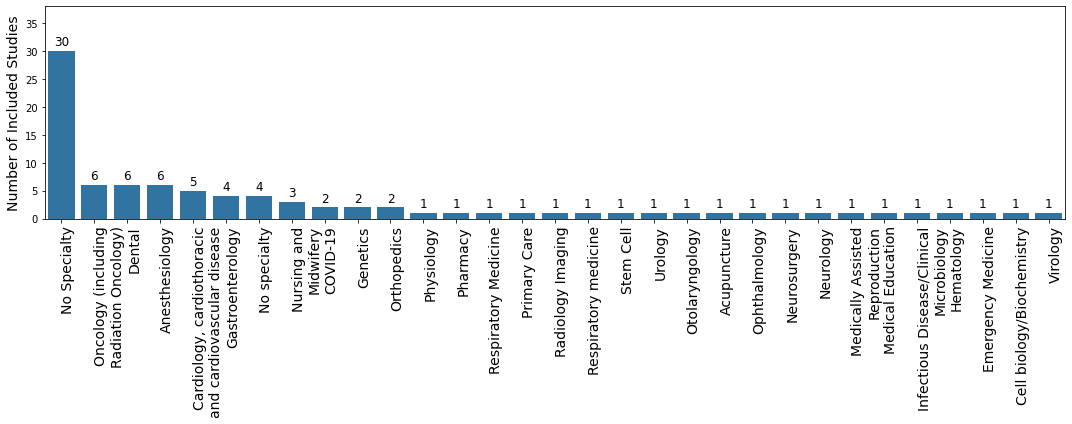

In [21]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.barplot(data=dfplt, x='subfield_studied', y='#Included Studies', ax=ax)

xticks = ax.get_xticks()
xtick_labels = []
for lbl in dfplt['subfield_studied'].tolist():
    lbl_split = lbl.split()
    n_words = len(lbl_split)
    if n_words > 2:
        #print(lbl)
        lbl_str = ' '.join(lbl_split[:2]) + '\n' + ' '.join(lbl_split[2:])
    else:
        lbl_str = lbl
    xtick_labels.append(lbl_str.strip())
    
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, rotation=90, ha='right', va='top', rotation_mode='anchor', size=14)

for xpos, count in zip(xticks, dfplt['#Included Studies'].tolist()):
    ax.text(x=xpos, y=count+1, s=str(count), ha='center', size=12) 
    
ax.set_ylim(0, 38)
ax.set_xlabel('')
ax.set_ylabel('Number of Included Studies', size=14)

plt.tight_layout()

plt.savefig('figs/med_subfields.png')

plt.show()

# Washout

In [22]:
washout = data[['EPPIReviewer ID', 'WashoutPeriod', 'WashoutPeriod_FreeText']].copy()
washout['WashoutPeriod'].unique()

array(['The authors do not mention washout periods',
       'The authors include a washout period',
       'The authors discuss washout periods, but do not use one'],
      dtype=object)

In [23]:
txt0 = '"Post-retraction citation was defined as any publication that cited a retracted article after retraction notices were published. The date of submission of citing articles was after the date of retraction notice publication. Concerning thosemarticles whose date of submission was unavailable, a publication was considered as post-retraction citation if it was published later than 6 months after the date of retraction"'
txt1 = 'seems to have varied by article - articles were "retracted between 1995 and 2014" "since data were collected on October 2014, and citation that appears from 2015 onwards is definitely a post retraction citation" - reported in each of the 15 cases'
txt2 = 'Approximately one month after retraction'
washout['WashoutPeriod2'] = washout['WashoutPeriod_FreeText']
washout.loc[washout['WashoutPeriod_FreeText']==txt0, 'WashoutPeriod2'] = 'Published after the publication of retraction notice'
washout.loc[washout['WashoutPeriod_FreeText']==txt1, 'WashoutPeriod2'] = "Published after sample's final retraction notice"
washout.loc[washout['WashoutPeriod_FreeText']==txt2, 'WashoutPeriod2'] = "1 month after retraction"

washout['WashoutPeriod_FreeText'] = washout['WashoutPeriod_FreeText'].fillna('NA')

In [24]:
washout_df = washout.groupby(['WashoutPeriod', 'WashoutPeriod2'])[['EPPIReviewer ID']].count()
washout_df = washout_df.sort_values(by=['WashoutPeriod', 'EPPIReviewer ID'], ascending=False)
print(washout_df.shape)
washout_df

(16, 1)


EPPIReviewer ID
WashoutPeriod                        WashoutPeriod2                                                                   
The authors include a washout period Following calendar year                                                        20
                                     1 year after retraction                                                         8
                                     Calendar year after sample's final retraction notice                            4
                                     6 months after retraction                                                       2
                                     1 month after retraction                                                        1
                                     1 month following retraction                                                    1
                                     1 year, 2 years, and 3 years                                                    1
                                     2 months after retraction                                                       1
                                     2 years after retraction                                                        1
                                     Published after sample's final retraction notice                                1
                                     Published after the publication of retraction notice                            1
                                     Second calendar year following retraction                                       1
                                     Submission date                                                                 1
                                     Year after the following calendar year                                          1
                                     Year of retraction plus subsequent year                                         1
                                     within 12 months after retraction; 12-36 months after retraction                1

# Taxonomies

In [25]:
q1 = 'Does this paper consider citation sentiment (e.g., positive-neutral-negative) or awareness (retraction status mentioned/non-mentioned)?'
q2 = 'For publications that assessed citation sentiment and/or awareness, what taxonomies were used? - Selected Choice'
q3 = 'For publications that assessed citation sentiment and/or awareness, what taxonomies were used? - Other - Text'
taxonomies = data[['EPPIReviewer ID', q1, q2, q3, 'Year']].copy()
taxonomies = taxonomies.rename(columns={q1: 'sentiment_awarness_considered',
                                        q2: 'sentiment_awarness_taxonomies', 
                                        q3: 'sentiment_awarness_taxonomies_freetxt'})
print(taxonomies.info())
taxonomies.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   EPPIReviewer ID                        146 non-null    int64 
 1   sentiment_awarness_considered          146 non-null    object
 2   sentiment_awarness_taxonomies          60 non-null     object
 3   sentiment_awarness_taxonomies_freetxt  16 non-null     object
 4   Year                                   145 non-null    Int64 
dtypes: Int64(1), int64(1), object(3)
memory usage: 6.0+ KB
None


,EPPIReviewer ID,sentiment_awarness_considered,sentiment_awarness_taxonomies,sentiment_awarness_taxonomies_freetxt,Year
0,110101865,No,NaN,NaN,2023
1,110101885,No,NaN,NaN,2022


In [26]:
taxonomies.loc[~taxonomies['sentiment_awarness_taxonomies_freetxt'].isna()]['sentiment_awarness_taxonomies'].unique()

array(['Aware/Unaware;Other', 'Other',
       'Citation location (e.g., Methods, Limitations);Other',
       'Aware/Unaware;Positive/Negative/Neutral;Other',
       'Citation location (e.g., Methods, Limitations)'], dtype=object)

In [27]:
taxonomies.loc[~taxonomies['sentiment_awarness_taxonomies_freetxt'].isna()]

,EPPIReviewer ID,sentiment_awarness_considered,sentiment_awarness_taxonomies,sentiment_awarness_taxonomies_freetxt,Year
33,110102059,Yes,Aware/Unaware;Other,Affirmative;Assumptive;Conceptual;Contrastive;Methodologic;Negative;Perfunctory;and Persuasive,2019
35,110102064,Yes,Other,Acknowledged;Explicitly positive;Implicitly positive,1998
40,110102092,Yes,"Citation location (e.g., Methods, Limitations);Other",With or without caution,2022
69,110104139,Yes,Other,Conflicting;Ambiguous;Highly cocited;Orienting reference list;Supporting;Opposition;Skepticism;Uncertainty,2024
70,110104228,Yes,Other,Related work or use—Citations referencing related work or using content from within a retraction.;Comparison of results—Compared findings to another paper;Corrections—Corrected an article based on...,2024
72,110104343,Yes,Aware/Unaware;Other,Positive;Negative,2024
86,110104563,Yes,Other,Background;Supportive;Contradictory;Manipulative,2023
90,110104874,Yes,Other,"Non-dependent (inconsistent, discuss);Dependent (consistent, build upon, use material)",2023
104,110105435,Yes,Aware/Unaware;Positive/Negative/Neutral;Other,Whether they described methods or results of the Matsuyama paper as opposed to citing a general concept,2020
115,110105803,Yes,"Citation location (e.g., Methods, Limitations)",Inclusion,2018


In [28]:
taxonomies.loc[taxonomies['sentiment_awarness_considered']=='No']['sentiment_awarness_taxonomies'].unique()

array([nan], dtype=object)

In [29]:
taxonomies.loc[taxonomies['sentiment_awarness_considered']=='No']['sentiment_awarness_taxonomies_freetxt'].unique()

array([nan], dtype=object)

In [30]:
taxonomies_ = []

has_taxonomies = taxonomies.loc[taxonomies['sentiment_awarness_considered']=='Yes']
for i, row in has_taxonomies.iterrows():
    taxonomies_options = row['sentiment_awarness_taxonomies']
    taxonomies_options = taxonomies_options.split(';')
    if len(taxonomies_options) == 1:
        taxonomies_.append(taxonomies_options[0])
    else:
        taxonomies_.append('Multiple')
            
Counter(taxonomies_), sum(list(Counter(taxonomies_).values()))

(Counter({'Aware/Unaware': 18,
          'Positive/Negative/Neutral': 15,
          'Citation location (e.g., Methods, Limitations)': 4,
          'Multiple': 13,
          'Other': 10}),
 60)

In [31]:
taxonomies_df_prep = {'Aware/Unaware': 0, 'Positive/Negative/Neutral': 0, 
                      'Citation location (e.g., Methods, Limitations)': 0, 'Other': 0}

has_taxonomies = taxonomies.loc[taxonomies['sentiment_awarness_considered']=='Yes']
for i, row in has_taxonomies.iterrows():
    taxonomies_options = row['sentiment_awarness_taxonomies']
    taxonomies_freetxt = row['sentiment_awarness_taxonomies_freetxt']
    
    taxonomies_options = taxonomies_options.split(';')
    
    if isinstance(taxonomies_freetxt, str):
        taxonomies_freetxt = taxonomies_freetxt.split(';')
    else:
        taxonomies_freetxt = []
    
    for taxonomies_option in taxonomies_options:
        if taxonomies_option in ['Aware/Unaware', 'Positive/Negative/Neutral', 
                                 'Citation location (e.g., Methods, Limitations)']:
            taxonomies_df_prep[taxonomies_option] += 1
        else:
            if 'Citation location (e.g., Methods, Limitations)' in taxonomies_freetxt:
                if len(taxonomies_freetxt) == 1:
                    taxonomies_df_prep['Citation location (e.g., Methods, Limitations)'] += 1
                else:
                    taxonomies_df_prep['Citation location (e.g., Methods, Limitations)'] += 1
                    taxonomies_df_prep[taxonomies_option] += 1
            else:
                taxonomies_df_prep[taxonomies_option] += 1

taxonomies_df = pd.DataFrame({'Taxonomy': taxonomies_df_prep.keys(), 
                              '#Included Studies':taxonomies_df_prep.values()})
taxonomies_df

,Taxonomy,#Included Studies
0,Aware/Unaware,28
1,Positive/Negative/Neutral,21
2,"Citation location (e.g., Methods, Limitations)",11
3,Other,15


In [32]:
taxonomy_yn_yr = taxonomies.groupby(['Year', 'sentiment_awarness_considered'])[['EPPIReviewer ID']].count()
taxonomy_yn_yr = taxonomy_yn_yr.rename(columns={'EPPIReviewer ID': '#Included Studies'})
taxonomy_yn_yr = taxonomy_yn_yr.reset_index()
taxonomy_yn_yr

,Year,sentiment_awarness_considered,#Included Studies
0,1990,No,1
1,1991,Yes,1
2,1992,Yes,1
3,1994,No,1
4,1998,Yes,1
5,1999,Yes,1
6,2006,Yes,2
7,2008,No,1
8,2008,Yes,1
9,2009,No,1


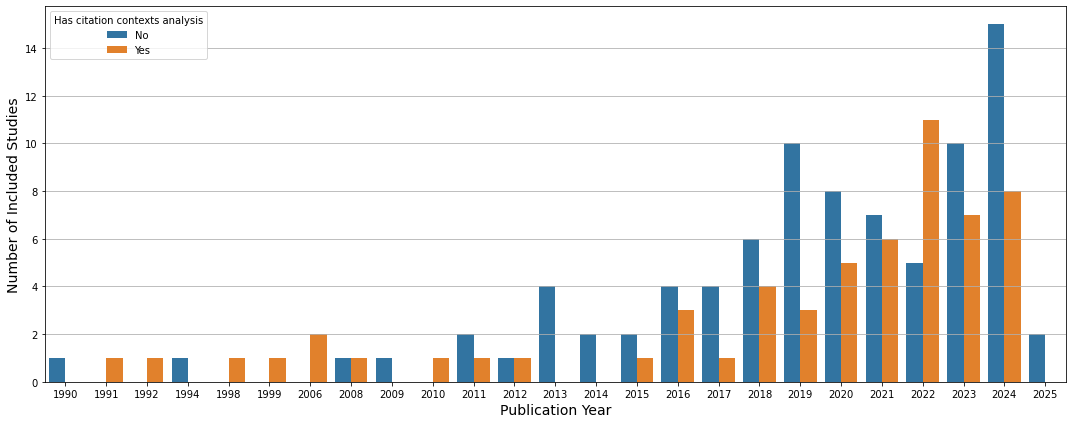

In [33]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.barplot(data=taxonomy_yn_yr, x="Year", y="#Included Studies", hue="sentiment_awarness_considered")

ax.set_xlabel('Publication Year', size=14)
ax.set_ylabel('Number of Included Studies', size=14)

ax.grid(axis='y')
ax.legend(title='Has citation contexts analysis')

plt.tight_layout()
plt.savefig('figs/sentiment_aware_considered.png')
plt.show()